In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
file_path = '/content/Road Accidents.xlsx'
df = pd.read_excel(file_path, sheet_name='2011-1')

In [14]:
df.shape

(2604, 15)

In [15]:
df.isnull().sum()

,0
Reference Number,0
Easting,0
Northing,0
Number of Vehicles,0
Accident Date,0
Time (24hr),0
1st Road Class,0
Road Surface,0
Lighting Conditions,0
Weather Conditions,0


In [13]:
df.head()

,Reference Number,Easting,Northing,Number of Vehicles,Accident Date,Time (24hr),1st Road Class,Road Surface,Lighting Conditions,Weather Conditions,Casualty Class,Casualty Severity,Sex of Casualty,Age of Casualty,Type of Vehicle
0,110016014,443330,439205,2,2011-01-12,712,1,3,1,5,0,2,1,62,2
1,110016024,425059,433371,2,2011-01-12,830,4,3,4,5,0,2,0,39,2
2,110016533,420683,434373,1,2011-01-12,1215,0,3,4,1,2,1,1,66,2
3,110017112,431097,433000,1,2011-01-12,1735,0,1,2,1,2,1,1,39,3
4,110020375,429523,433820,2,2011-01-12,1230,0,1,4,1,0,2,1,29,2


In [3]:
target_col = 'Casualty Severity'
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    if df[col].apply(lambda x: isinstance(x, (str, int))).all():
        df[col] = df[col].astype(str)
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    else:
        print(f"Skipping column '{col}' due to mixed data types.")

In [4]:
X = df.drop(columns=[target_col])
y = LabelEncoder().fit_transform(df[target_col])
y_cat = to_categorical(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=42
)

In [6]:
for col in X_train.select_dtypes(include=['datetime64']).columns:
    X_train[col] = X_train[col].astype('int64')
    X_test[col] = X_test[col].astype('int64')

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
rf = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train.argmax(axis=1))
rf_preds = rf.predict(X_test)

print("\n Random Forest Classification Report:")
print(classification_report(y_test.argmax(axis=1), rf_preds))


 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.20      0.02      0.03        53
           2       0.89      0.99      0.94       463

    accuracy                           0.89       521
   macro avg       0.70      0.40      0.44       521
weighted avg       0.82      0.89      0.84       521



In [11]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)


loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n Accuracy: {accuracy * 100:.2f}%")

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7127 - loss: 0.7239 - val_accuracy: 0.8947 - val_loss: 0.3383
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8794 - loss: 0.4113 - val_accuracy: 0.8947 - val_loss: 0.3211
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8784 - loss: 0.4001 - val_accuracy: 0.8947 - val_loss: 0.3151
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8895 - loss: 0.3515 - val_accuracy: 0.8947 - val_loss: 0.3124
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8866 - loss: 0.3523 - val_accuracy: 0.8947 - val_loss: 0.3081
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8941 - loss: 0.3339 - val_accuracy: 0.8947 - val_loss: 0.3080
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8954 - loss: 0.3253 - val_accuracy: 0.8947 - val_loss: 0.3067
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8755 - loss: 0.3711 - val_accuracy: 0.8947 - val_loss:

In [16]:
from imblearn.over_sampling import SMOTE


y_train_labels = y_train.argmax(axis=1)


smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_labels)


rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)


rf_preds = rf.predict(X_test)


print(" Updated Classification Report with SMOTE:")
print(classification_report(y_test.argmax(axis=1), rf_preds))


 Updated Classification Report with SMOTE:
              precision    recall  f1-score   support

           0       0.25      0.20      0.22         5
           1       0.30      0.30      0.30        53
           2       0.92      0.92      0.92       463

    accuracy                           0.85       521
   macro avg       0.49      0.47      0.48       521
weighted avg       0.85      0.85      0.85       521



In [17]:
import numpy as np
print("Before SMOTE:", np.bincount(y_train_labels))
print("After SMOTE:", np.bincount(y_train_resampled))


Before SMOTE: [  20  213 1850]
After SMOTE: [1850 1850 1850]


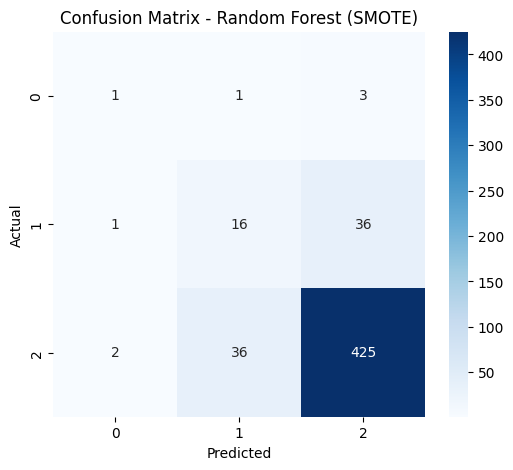

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test.argmax(axis=1), rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


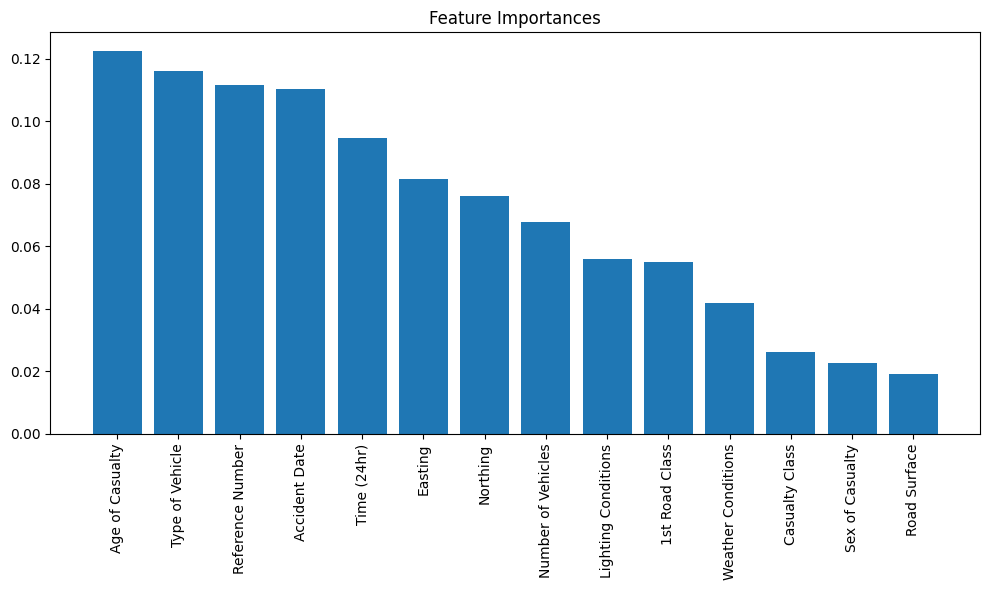

In [19]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train_scaled, y_train, epochs=100, batch_size=32,
          validation_split=0.1, verbose=1, callbacks=[early_stop])


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9133 - loss: 0.2615 - val_accuracy: 0.8900 - val_loss: 0.2971
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9032 - loss: 0.2658 - val_accuracy: 0.8900 - val_loss: 0.2961
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9039 - loss: 0.2545 - val_accuracy: 0.8900 - val_loss: 0.2967
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9004 - loss: 0.2629 - val_accuracy: 0.8900 - val_loss: 0.3080
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9101 - loss: 0.2533 - val_accuracy: 0.8900 - val_loss: 0.3024
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8913 - loss: 0.2718 - val_accuracy: 0.8900 - val_loss: 0.2995
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8902 - loss: 0.2926 - val_accuracy: 0.8900 - val_loss: 0.3045


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score


models = {
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')  # for multi-class
}


results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test.argmax(axis=1), preds)
    f1 = f1_score(y_test.argmax(axis=1), preds, average='weighted')
    report = classification_report(y_test.argmax(axis=1), preds, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1
    })

    print(f"\n📌 Classification Report for {name}")
    print(classification_report(y_test.argmax(axis=1), preds))


results_df = pd.DataFrame(results)
print("\n Model Comparison Table:")
print(results_df.sort_values(by='F1-Score', ascending=False))



📌 Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.25      0.20      0.22         5
           1       0.30      0.30      0.30        53
           2       0.92      0.92      0.92       463

    accuracy                           0.85       521
   macro avg       0.49      0.47      0.48       521
weighted avg       0.85      0.85      0.85       521


📌 Classification Report for Logistic Regression
              precision    recall  f1-score   support

           0       0.01      1.00      0.02         5
           1       0.00      0.00      0.00        53
           2       0.00      0.00      0.00       463

    accuracy                           0.01       521
   macro avg       0.00      0.33      0.01       521
weighted avg       0.00      0.01      0.00       521



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


📌 Classification Report for SVM
              precision    recall  f1-score   support

           0       0.01      0.40      0.01         5
           1       0.13      0.62      0.21        53
           2       0.00      0.00      0.00       463

    accuracy                           0.07       521
   macro avg       0.05      0.34      0.08       521
weighted avg       0.01      0.07      0.02       521


📌 Classification Report for Decision Tree
              precision    recall  f1-score   support

           0       0.09      0.20      0.12         5
           1       0.27      0.45      0.34        53
           2       0.93      0.84      0.88       463

    accuracy                           0.80       521
   macro avg       0.43      0.50      0.45       521
weighted avg       0.85      0.80      0.82       521


📌 Classification Report for Gradient Boosting
              precision    recall  f1-score   support

           0       0.09      0.20      0.12         5
      

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📌 Classification Report for XGBoost
              precision    recall  f1-score   support

           0       0.25      0.20      0.22         5
           1       0.24      0.21      0.22        53
           2       0.91      0.92      0.91       463

    accuracy                           0.84       521
   macro avg       0.47      0.44      0.45       521
weighted avg       0.83      0.84      0.84       521


 Model Comparison Table:
                 Model  Accuracy  F1-Score
0        Random Forest  0.848369  0.847702
6              XGBoost  0.842610  0.837297
4    Gradient Boosting  0.808061  0.825961
3        Decision Tree  0.798464  0.821722
5                  KNN  0.765835  0.792524
2                  SVM  0.067179  0.021663
1  Logistic Regression  0.009597  0.000182


<ipython-input-22-4a00f7a14f28>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.sort_values(by='F1-Score', ascending=False), x='F1-Score', y='Model', palette='viridis')


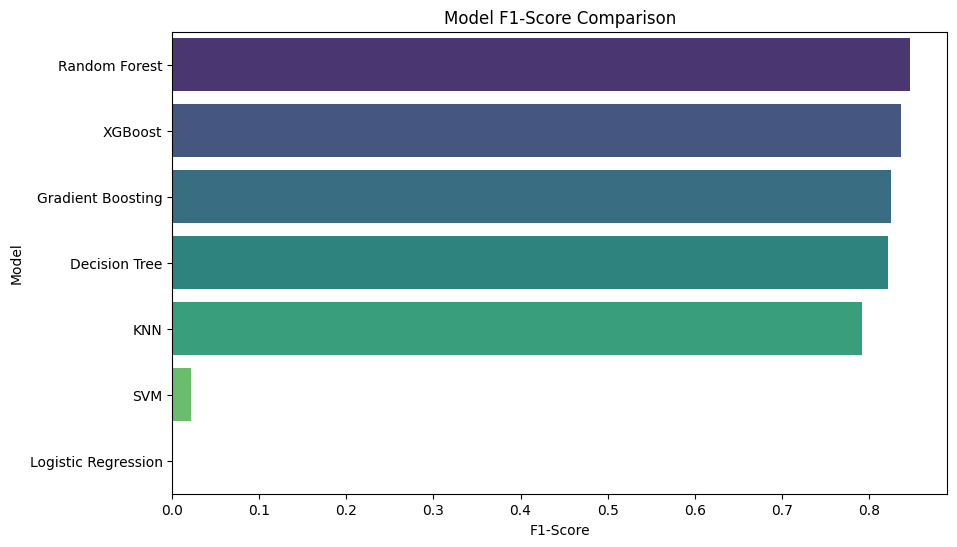

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.sort_values(by='F1-Score', ascending=False), x='F1-Score', y='Model', palette='viridis')
plt.title("Model F1-Score Comparison")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/multiclass.py:557: RuntimeWarning: invalid value encountered in divide
  Y /= np.sum(Y, axis=1)[:, np.newaxis]
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:08:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:08:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:08:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


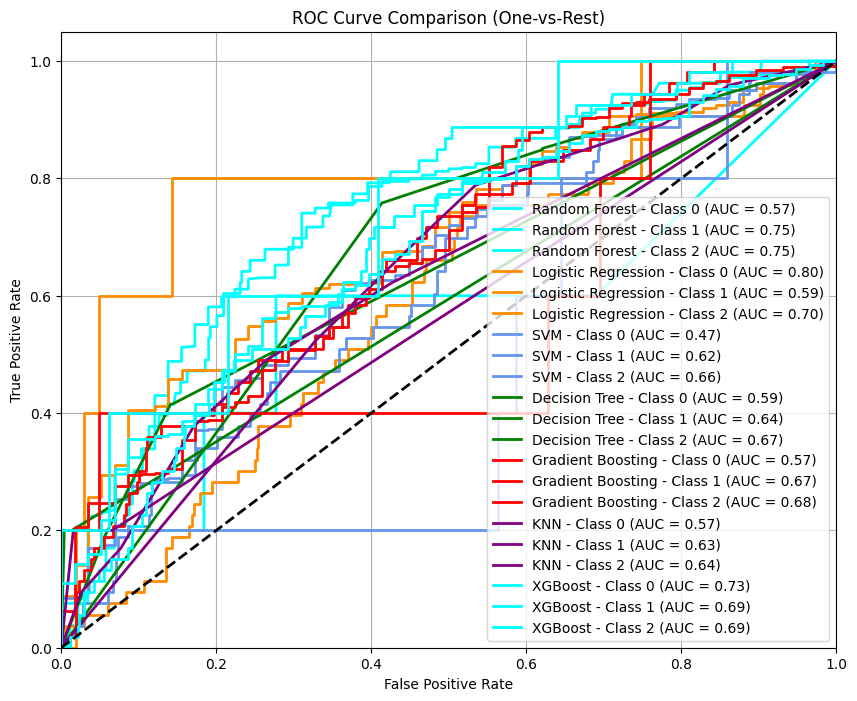

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from itertools import cycle



y_test_bin = label_binarize(y_test.argmax(axis=1), classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])

for (name, model), color in zip(models.items(), colors):
    if name == "SVM":
        model = SVC(probability=True)

    if name in ["Logistic Regression", "SVM", "KNN"]:
        ovr = OneVsRestClassifier(make_pipeline(StandardScaler(), model))
    else:
        ovr = OneVsRestClassifier(model)

    if name == "XGBoost":

        ovr.estimator.set_params(num_class=n_classes)

    ovr.fit(X_train_resampled, y_train_resampled)
    y_score = ovr.predict_proba(X_test)

    y_score = np.nan_to_num(y_score)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} - Class {i} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                           param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

print(" Best Params for Random Forest:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
best_rf_preds = best_rf.predict(X_test)

print("\n Tuned Random Forest Classification Report:")
print(classification_report(y_test.argmax(axis=1), best_rf_preds))


 Best Params for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}

 Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.20      0.20         5
           1       0.30      0.30      0.30        53
           2       0.92      0.91      0.91       463

    accuracy                           0.84       521
   macro avg       0.47      0.47      0.47       521
weighted avg       0.85      0.84      0.85       521

